In [11]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [12]:
import json
import torch
from IPython.display import HTML
from src.cnn_lstm_v2 import CNNLSTMV2
from src.XAI.smooth_gradcam import SmoothGradCAM
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_gradcam_over_rgb, plot_single_frame_gradcam, animate_saliency_over_rgb
from scripts.common.get_device import get_available_device

experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_1" / "baseline"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

model = CNNLSTMV2(
    hidden_channels=hyperparameters["hidden_channels"],
    reduced_channels=hyperparameters["reduced_channels"],
    classifier_hidden_size=hyperparameters["classifier_hidden_size"],
    dropout=hyperparameters["dropout"],
    cnn_cutoff=hyperparameters["cnn_cutoff"],
    cnn_unfreeze_from=hyperparameters["cnn_unfreeze_from"]
).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

dataset = RWF2000Dataset(
    DATASET_ROOT, 
    num_frames=hyperparameters["num_frames"], 
    input_mode=hyperparameters["input_mode"], 
    augment=False, 
    split="val", 
    return_rgb_frames=True
)

video_num = 300
video, label, rgb_frames = dataset[video_num]
video_batch = video.unsqueeze(0).to(device)
# [1, 32, 3, 224, 224]

label = label.item()

Using cuda:3 with 20.55 GB free


In [13]:
smooth_cam = SmoothGradCAM(model, model.cnn[-1], num_samples=50, normalisation_mode="per_video", noise_mode="per_video")
cams, logits = smooth_cam.generate_heatmap(video_batch)
prediction = torch.argmax(logits, dim=1).item()
smooth_cam.remove_hooks()

heatmap = cams[0]

processed 0/50
processed 1/50
processed 2/50
processed 3/50
processed 4/50
processed 5/50
processed 6/50
processed 7/50
processed 8/50
processed 9/50
processed 10/50
processed 11/50
processed 12/50
processed 13/50
processed 14/50
processed 15/50
processed 16/50
processed 17/50
processed 18/50
processed 19/50
processed 20/50
processed 21/50
processed 22/50
processed 23/50
processed 24/50
processed 25/50
processed 26/50
processed 27/50
processed 28/50
processed 29/50
processed 30/50
processed 31/50
processed 32/50
processed 33/50
processed 34/50
processed 35/50
processed 36/50
processed 37/50
processed 38/50
processed 39/50
processed 40/50
processed 41/50
processed 42/50
processed 43/50
processed 44/50
processed 45/50
processed 46/50
processed 47/50
processed 48/50
processed 49/50


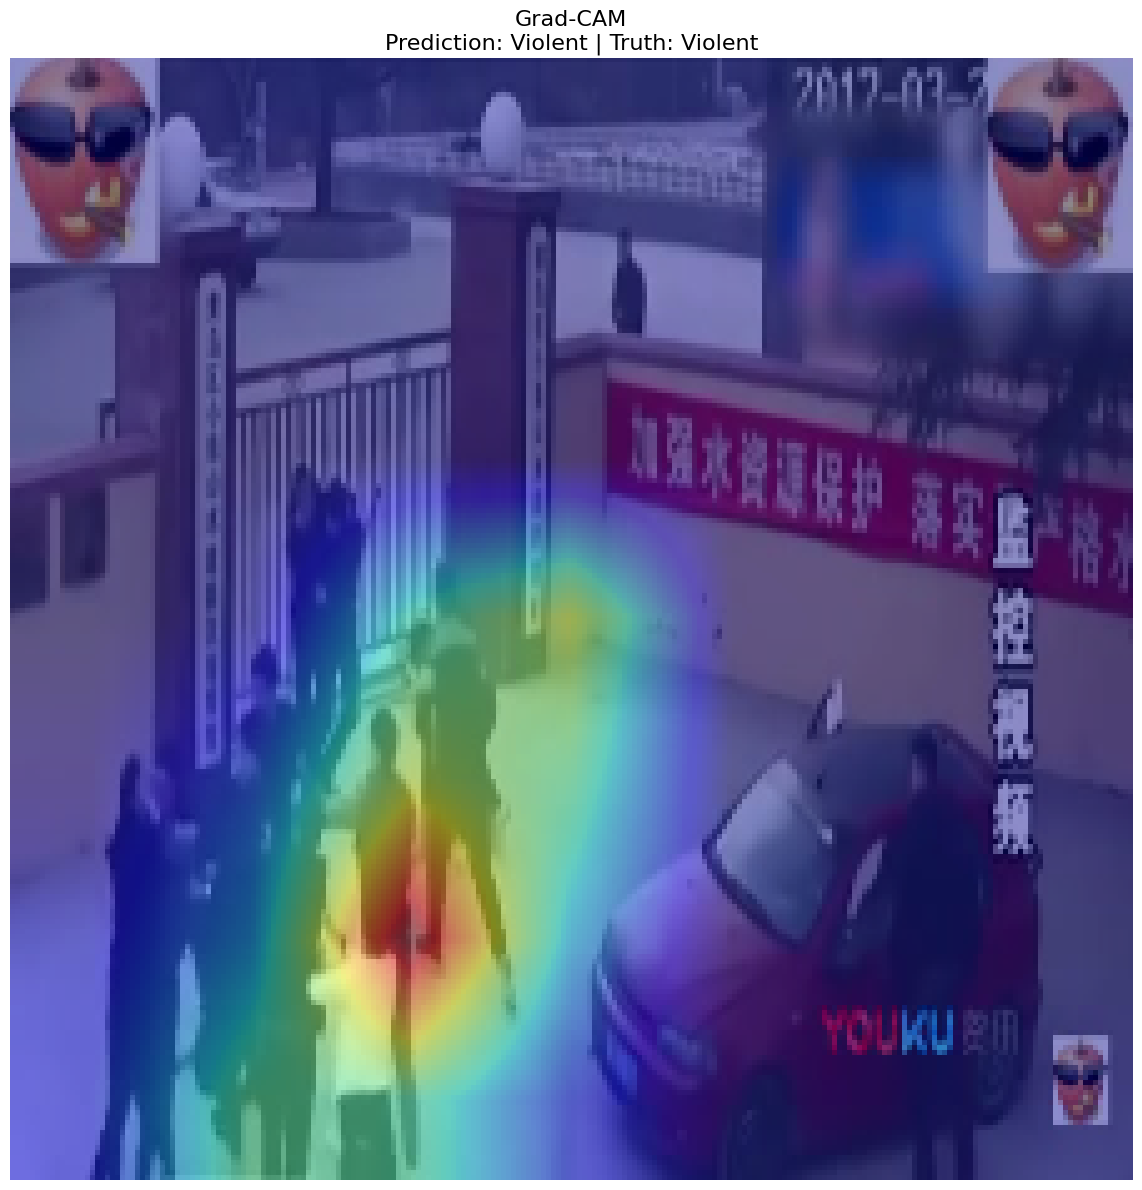

In [17]:
# plot single frame
frame_index = 27  # Change this index to visualize different frames
plot_single_frame_gradcam(heatmap, rgb_frames,frame_index, label, prediction, alpha=0.45)

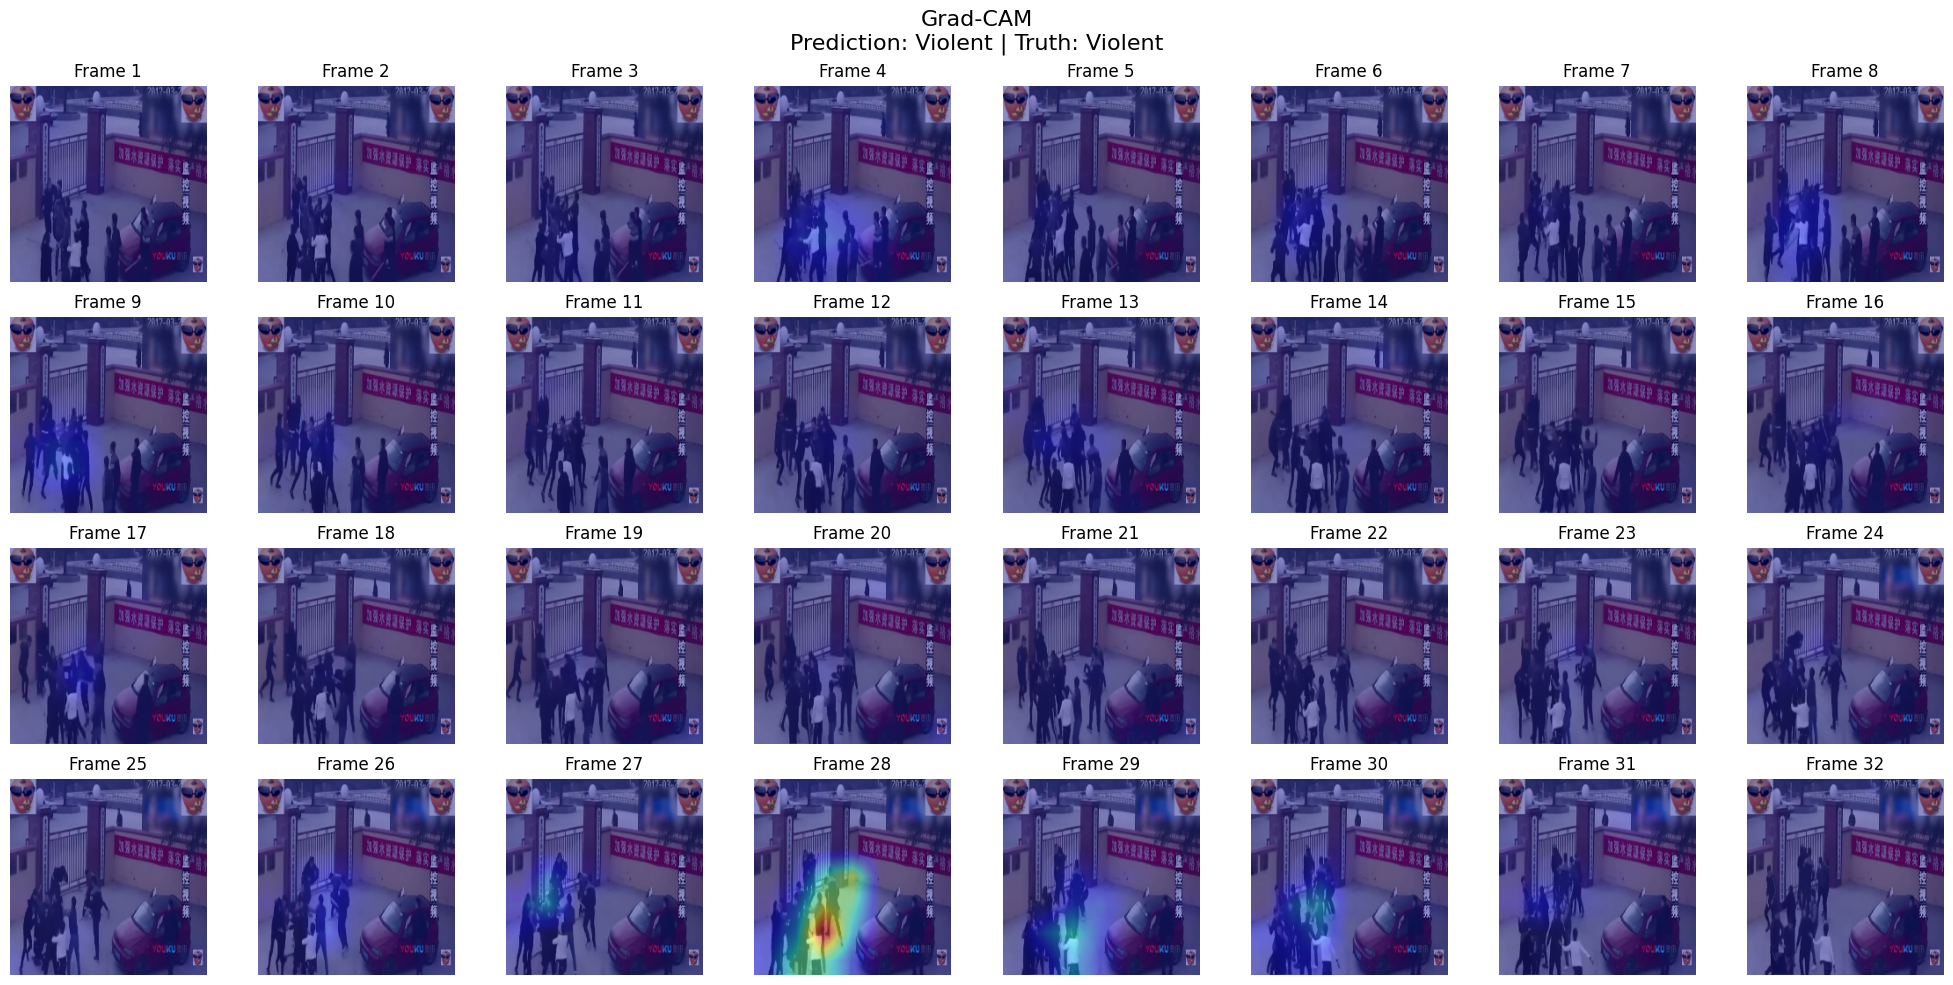

In [15]:
# plot all frames
plot_gradcam_over_rgb(heatmap, rgb_frames, label, prediction, alpha=0.45)

In [ ]:
# plot video
animation = animate_saliency_over_rgb(heatmap, rgb_frames, label, prediction)
HTML(animation.to_jshtml())